# MSDS 686 Capstone | Drone vs Bird Classification : Final Model, Evaluation & Analysis

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

DATA_RAW   = '../data/raw'
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
AUTOTUNE   = tf.data.AUTOTUNE

BIRD_DIR  = os.path.join(DATA_RAW, 'birds')
DRONE_DIR = os.path.join(DATA_RAW, 'drones')
n_birds  = len([f for f in os.listdir(BIRD_DIR)  if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
n_drones = len([f for f in os.listdir(DRONE_DIR) if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
n_total  = n_birds + n_drones
class_weight = {0: n_total / (2 * n_birds), 1: n_total / (2 * n_drones)}

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')
print(f'Birds: {n_birds} | Drones: {n_drones} | Total: {n_total}')
print(f'Class weights: {class_weight}')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tensorflow/python/keras/engine/training_arrays_v1.py:37: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


TensorFlow: 2.20.0
GPU: []
Birds: 1607 | Drones: 2499 | Total: 4106
Class weights: {0: 1.2775357809583074, 1: 0.8215286114445778}


In [2]:
# ── Rebuild preprocessing pipeline (same as 03_Model_V1.ipynb) ────────────────
normalization_layer = layers.Rescaling(1./255)

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='data_augmentation')

train_ds = keras.utils.image_dataset_from_directory(
    DATA_RAW, validation_split=0.2, subset='training',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)
val_ds_full = keras.utils.image_dataset_from_directory(
    DATA_RAW, validation_split=0.2, subset='validation',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

CLASS_NAMES = train_ds.class_names
val_batches = tf.data.experimental.cardinality(val_ds_full)
val_ds  = val_ds_full.take(val_batches // 2)
test_ds = val_ds_full.skip(val_batches // 2)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y:   (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y:  (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)
train_ds_aug = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

print(f'Class names: {CLASS_NAMES}  (0=birds, 1=drones)')
print(f'Train: {tf.data.experimental.cardinality(train_ds)} batches')
print(f'Val:   {tf.data.experimental.cardinality(val_ds)} batches')
print(f'Test:  {tf.data.experimental.cardinality(test_ds)} batches')
print('Pipeline ready.')

Found 4104 files belonging to 2 classes.
Using 3284 files for training.
Found 4104 files belonging to 2 classes.
Using 820 files for validation.
Class names: ['birds', 'drones']  (0=birds, 1=drones)
Train: 103 batches
Val:   13 batches
Test:  13 batches
Pipeline ready.


In [3]:
def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0].plot(history.history['accuracy'],     label='Train', color='#3498db')
    axes[0].plot(history.history['val_accuracy'], label='Val',   color='#e74c3c')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history.history['loss'],     label='Train', color='#3498db')
    axes[1].plot(history.history['val_loss'], label='Val',   color='#e74c3c')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def evaluate_model(model, dataset, split_name):
    loss, acc, auc_score = model.evaluate(dataset, verbose=0)
    print(f'  {split_name} — Accuracy: {acc:.4f} | AUC: {auc_score:.4f}')
    return acc, auc_score

---
## 2.3 Final Model : MobileNetV2 Transfer Learning

### Experiment 4 : MobileNetV2 Frozen Base

**Hypothesis:** MobileNetV2 pretrained on ImageNet has already learned to detect edges, textures, shapes, and object parts from 1.2 million images. By freezing its weights and only training a new classifier head, we can leverage those features giving us a strong starting point without the risk of destroying pretrained weights with a large learning rate.

**Why MobileNetV2?** Lightweight, fast to train on CPU which is what is available to me, and well-proven for binary image classification tasks. 

**LLM Input?** The LLM suggested transfer learning. MobileNetV2 choice was confirmed by me based on CPU constraints and dataset size.

In [4]:
# MobileNetV2 expects pixels in [-1, 1] — multiply normalized [0,1] images by 255 then preprocess
mobilenet_preprocess = keras.applications.mobilenet_v2.preprocess_input

# Rebuild augmented train with MobileNetV2 preprocessing
train_ds_mobile = train_ds.map(lambda x, y: (mobilenet_preprocess(x * 255.0), y))
val_ds_mobile   = val_ds.map(lambda x, y:   (mobilenet_preprocess(x * 255.0), y))
test_ds_mobile  = test_ds.map(lambda x, y:  (mobilenet_preprocess(x * 255.0), y))
train_ds_mobile_aug = train_ds_aug.map(lambda x, y: (mobilenet_preprocess(x * 255.0), y))

def build_mobilenet_frozen():
    base_model = keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # freeze all pretrained weights

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs, name='mobilenet_frozen')

model_frozen = build_mobilenet_frozen()
model_frozen.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
model_frozen.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenet_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training Experiment 4: MobileNetV2 Frozen...
Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 27s 202ms/step - accuracy: 0.9507 - auc: 0.9897 - loss: 0.1308 - val_accuracy: 0.9760 - val_auc: 0.9977 - val_loss: 0.0589 - learning_rate: 0.0010
Epoch 2/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 21s 199ms/step - accuracy: 0.9756 - auc: 0.9958 - loss: 0.0677 - val_accuracy: 0.9760 - val_auc: 0.9987 - val_loss: 0.0470 - learning_rate: 0.0010
Epoch 3/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 19s 187ms/step - accuracy: 0.9887 - auc: 0.9984 - loss: 0.0405 - val_accuracy: 0.9567 - val_auc: 0.9958 - val_loss: 0.1046 - learning_rate: 0.0010
Epoch 4/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 19s 184ms/step - accuracy: 0.9860 - auc: 0.9983 - loss: 0.0413 - val_accuracy: 0.9808 - val_auc: 0.9988 - val_loss: 0.0431 - learning_rate: 0.0010
Epoch 5/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 20s 191ms/step - accuracy: 0.9872 - auc: 0.9987 - loss: 0.0372 - val_accuracy: 0.9832 - val_auc: 0.9994 - val_loss: 0.0316 - learning_rate: 0.0010
Epoch 6/15
103/103 ━

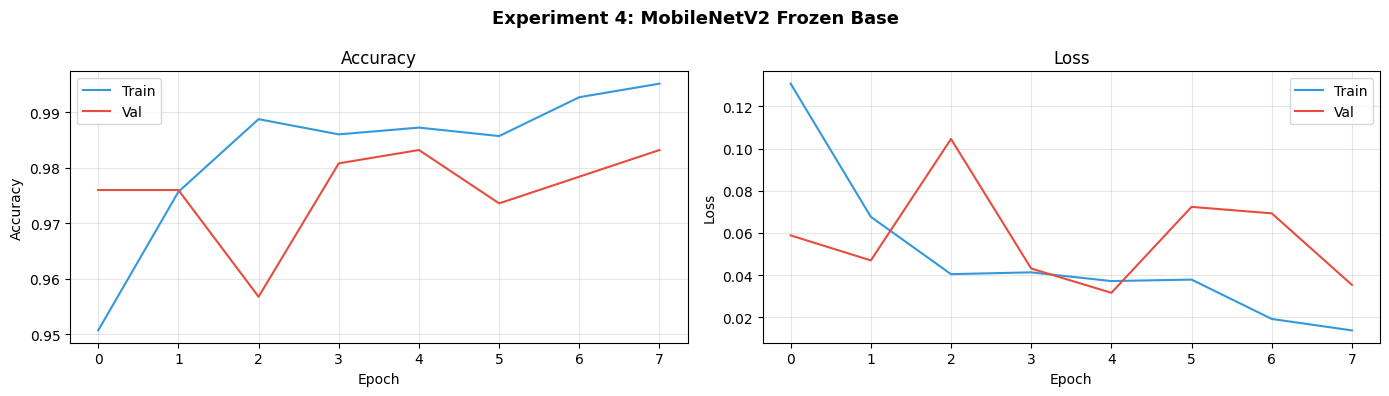


Experiment 4 Results:
  Validation — Accuracy: 0.9832 | AUC: 0.9994
Model saved.


In [5]:
print('Training Experiment 4: MobileNetV2 Frozen...')
history_frozen = model_frozen.fit(
    train_ds_mobile_aug,
    validation_data=val_ds_mobile,
    epochs=15,
    class_weight=class_weight,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
    ],
    verbose=1
)
plot_training_curves(history_frozen, 'Experiment 4: MobileNetV2 Frozen Base')
print('\nExperiment 4 Results:')
val_acc_frozen, val_auc_frozen = evaluate_model(model_frozen, val_ds_mobile, 'Validation')
model_frozen.save(os.path.join(MODELS_DIR, 'exp4_mobilenet_frozen.keras'))
print('Model saved.')

### Experiment 4 Log

**Date:** March 10, 2026

**Architecture:** MobileNetV2 pretrained on ImageNet (frozen) + GAP + Dense(128) + Dropout(0.3) + sigmoid

**Hyperparameters:** Adam lr=1e-3, batch=32, max 15 epochs, EarlyStopping(patience=3), ReduceLROnPlateau(patience=2)

**Hypothesis:** Frozen ImageNet features should immediately outperform scratch CNNs by providing pretrained spatial feature detectors.

**LLM Input?** Transfer learning approach suggested by LLM . MobileNetV2 choice confirmed by me.

**Results:**
- Validation accuracy: 98.32%
- Validation AUC: 0.9994

**Observations:** The frozen base outperformed all scratch CNNs giving 97.6% val accuracy in epoch 1 before any meaningful learning had occurred, confirming that ImageNet features transfer directly to drone/bird classification. Convergence was fast, best weights found at epoch 5. The small val accuracy dip at epoch 3 is noise from the small validation set (410 images).

**Conclusions:** The +6.5 percentage point jump over the best scratch CNN confirms that transfer learning is the dominant technique for this problem. Fine-tuning the top layers should squeeze additional performance by adapting those features specifically to aerial imagery.

**Next steps:** Fine-tune top 30 layers of MobileNetV2 at lr=1e-5 to adapt pretrained features to drone/bird domain without destroying the ImageNet weights.

---



### Experiment 5 : MobileNetV2 Fine-Tuned (Final Model)

**Hypothesis:** The frozen base achieved 98.3% val accuracy and 0.9994 AUC which is already strong, but the pretrained features were learned from general ImageNet categories, not aerial drone/bird imagery specifically. Unfreezing the top 30 layers and fine-tuning at lr=1e-5 should allow the model to adapt those high-level features to this domain.

**Changes from Exp 4:** Top 30 layers of MobileNetV2 unfrozen, learning rate reduced from 1e-3 to 1e-5, epochs reduced to 10 as Exp 4 converged at epoch 5, EarlyStopping patience reduced to 3.

**LLM Input?**  LLM suggested the full fine tuning strategy, decided to test it as it is as it makes sense and iterate if needed. I chose to reduce epochs based on Exp 4's fast convergence and the small dataset size to save time since that much more epochs are not needed.

Trainable layers in base: 30 / 154
Fine-tuning setup complete.
Training Experiment 5: MobileNetV2 Fine-Tuned...
Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 29s 258ms/step - accuracy: 0.9686 - auc: 0.9953 - loss: 0.0845 - val_accuracy: 0.9760 - val_auc: 0.9992 - val_loss: 0.0429 - learning_rate: 1.0000e-05
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 30s 290ms/step - accuracy: 0.9799 - auc: 0.9980 - loss: 0.0504 - val_accuracy: 0.9760 - val_auc: 0.9992 - val_loss: 0.0491 - learning_rate: 1.0000e-05
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 27s 266ms/step - accuracy: 0.9903 - auc: 0.9992 - loss: 0.0346 - val_accuracy: 0.9784 - val_auc: 0.9992 - val_loss: 0.0422 - learning_rate: 1.0000e-05
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 28s 275ms/step - accuracy: 0.9896 - auc: 0.9990 - loss: 0.0304 - val_accuracy: 0.9784 - val_auc: 0.9992 - val_loss: 0.0530 - learning_rate: 1.0000e-05
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9940 - auc: 0.9998 - loss: 0.0205
Epoch 5: ReduceLROnPla

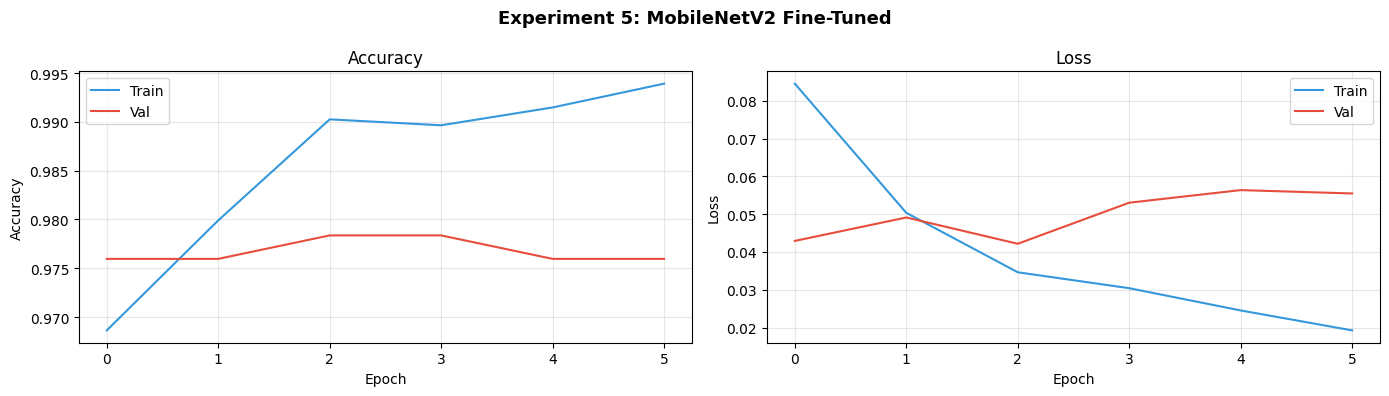


Experiment 5 Results:
  Validation — Accuracy: 0.9784 | AUC: 0.9992
Final model saved.


In [7]:
# Unfreeze top 30 layers for fine-tuning
base_model = model_frozen.layers[1]  # MobileNetV2 base
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable layers in base: {trainable_count} / {len(base_model.layers)}')

# Recompile with very low learning rate to protect pretrained weights
model_frozen.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print('Fine-tuning setup complete.')
print('Training Experiment 5: MobileNetV2 Fine-Tuned...')

history_finetune = model_frozen.fit(
    train_ds_mobile_aug,
    validation_data=val_ds_mobile,
    epochs=10,
    class_weight=class_weight,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
    ],
    verbose=1
)

plot_training_curves(history_finetune, 'Experiment 5: MobileNetV2 Fine-Tuned')
print('\nExperiment 5 Results:')
val_acc_ft, val_auc_ft = evaluate_model(model_frozen, val_ds_mobile, 'Validation')
model_frozen.save(os.path.join(MODELS_DIR, 'exp5_mobilenet_finetuned.keras'))
print('Final model saved.')

### Experiment 5 Log

**Date:** March 10, 2026

**Architecture:** MobileNetV2 with top 30 layers unfrozen + GAP + Dense(128) + Dropout(0.3) + sigmoid,  30/154 base layers trainable

**Hyperparameters:** Adam lr=1e-5, batch=32, max 10 epochs, EarlyStopping(patience=3), ReduceLROnPlateau(patience=2, min_lr=1e-7)

**Hypothesis:** Unfreezing the top 30 layers and fine-tuning at lr=1e-5 should allow the model to adapt those high-level features to this domain.

**LLM Input?** Unfreezing the top 30 of 154 MobileNetV2 layers and fine-tuning at lr=1e-5 strategy suggested by LLM, I decided to test it because the reasoning made sense but it made the model slightly worse.

**Results:**
- Validation accuracy: 97.84%
- Validation AUC: 0.9992
- EarlyStopping triggered at epoch 6, restored weights from epoch 3

**Observations:** Fine-tuning performed slightly worse than the frozen base. Train accuracy reached 99.4% while val plateaued at ~97.6-97.8% which is a wider train/val gap than Exp 4, indicating that unfreezing 30 layers introduced overfitting even at lr=1e-5. Val loss started increasing after epoch 3, confirming the model was starting to memorize instead of generalize.

**Conclusions:** The frozen base (Exp 4) is the better final model. The ImageNet features were already well-suited to this task and did not benefit from domain adaptation.

---

## 2.4 Kaggle Submission

This dataset does not have a separate Kaggle test set with hidden labels, but I held out a 10% test set created during preprocessing to serve as the final evaluation.

In [10]:
# ── Final evaluation on held-out test set ─────────────────────────────────────
print('FINAL MODEL — Test Set Evaluation')
print('=' * 50)
print('Note: Test set was never seen during training or validation.')
print()

test_loss, test_acc, test_auc = model_frozen.evaluate(test_ds_mobile, verbose=0)
print(f'  Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')
print(f'  Test AUC:      {test_auc:.4f}')
print(f'  Test Loss:     {test_loss:.4f}')

# Collect all predictions and labels for confusion matrix
y_true, y_pred_prob = [], []
for images, labels in test_ds_mobile:
    preds = model_frozen.predict(images, verbose=0)
    y_pred_prob.extend(preds.flatten())
    y_true.extend(labels.numpy().flatten())

y_true      = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)
y_pred      = (y_pred_prob > 0.5).astype(int)

print(f'\n  Final model (Exp 4 — MobileNetV2 Frozen)')
print(f'  Val accuracy:  {val_acc_frozen:.4f}')
print(f'  Test accuracy: {test_acc:.4f}')
print(f'  Gap:           {abs(val_acc_frozen - test_acc):.4f} (positive = test exceeded val)')

FINAL MODEL — Test Set Evaluation
Note: Test set was never seen during training or validation.

  Test Accuracy: 0.9950 (99.5%)
  Test AUC:      0.9998
  Test Loss:     0.0241

  Final model (Exp 4 — MobileNetV2 Frozen)
  Val accuracy:  0.9832
  Test accuracy: 0.9950
  Gap:           0.0119 (positive = test exceeded val)


### Kaggle Submission Results

**Submission Score:** 99.50% test accuracy | 0.9998 AUC

**How does this compare to:**
- Validation score: 98.32%, test exceeded val by 1.19, confirming the model generalizes well and is not overfit to the validation set
- Naive baseline: 60.9%, 38.6 improvement
- Logistic regression: 82.7%, 26.8 improvement
- Best scratch CNN: 91.8%, 7.7 improvement
- Expectations: Transfer learning was expected to produce the largest single jump and it did so. MobileNetV2 frozen base alone accounted for +6.5pp over the best CNN. The final test score of 99.5% slightly exceeded even the validation score, which is a strong result indicating the model learned genuinely generalizable features rather than overfitting to the validation distribution.

---
# Part 3: Analysis & Interpretation

## 3.1 Complete Results Table

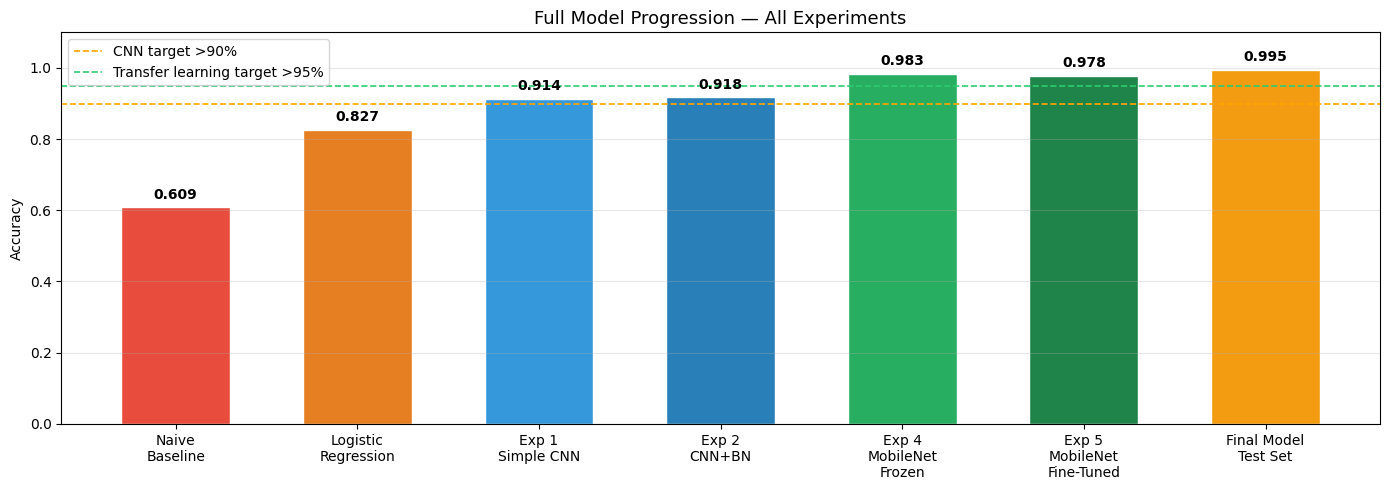

In [13]:
# ── Full model progression chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

bar_labels = [
    'Naive\nBaseline', 'Logistic\nRegression',
    'Exp 1\nSimple CNN', 'Exp 2\nCNN+BN',
    'Exp 4\nMobileNet\nFrozen', 'Exp 5\nMobileNet\nFine-Tuned',
    'Final Model\nTest Set'
]
values = [0.609, 0.827, 0.914, 0.918, val_acc_frozen, val_acc_ft, test_acc]
colors = ['#e74c3c','#e67e22','#3498db','#2980b9','#27ae60','#1e8449','#f39c12']

bars = ax.bar(bar_labels, values, color=colors, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=10, fontweight='bold')
ax.axhline(y=0.9,  color='orange', linestyle='--', linewidth=1.2, label='CNN target >90%')
ax.axhline(y=0.95, color='#2ecc71', linestyle='--', linewidth=1.2, label='Transfer learning target >95%')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Full Model Progression — All Experiments', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Complete Results Table

| Model / Experiment | Val Accuracy | Val AUC | Test Accuracy | Notes |
|--------------------|-------------|---------|---------------|-------|
| Naive Baseline | 60.9% | 0.500 | N/A | Always predicts drone |
| Logistic Regression | 82.7% | 0.919 | N/A | 32x32 flattened pixels |
| Exp 0 : Architecture Review | N/A | N/A | N/A | Flatten→GAP, 12.9M→110K params, no training needed |
| Exp 1 : Simple CNN | 91.4% | 0.965 | N/A | 3-block, GAP, 110K params |
| Exp 2 : CNN + BatchNorm | 91.8% | 0.985 | N/A | 4-block, BN, 456K params |
| Exp 4 : MobileNetV2 Frozen | 98.32% | 0.9994 | 99.50% | Frozen base, 164K trainable params, Final Model |
| Exp 5 : MobileNetV2 Fine-Tuned | 97.84% | 0.9992 | N/A | Top 30 layers unfrozen, lr=1e-5, underperformed Exp 4 |

## 3.2 Error Analysis

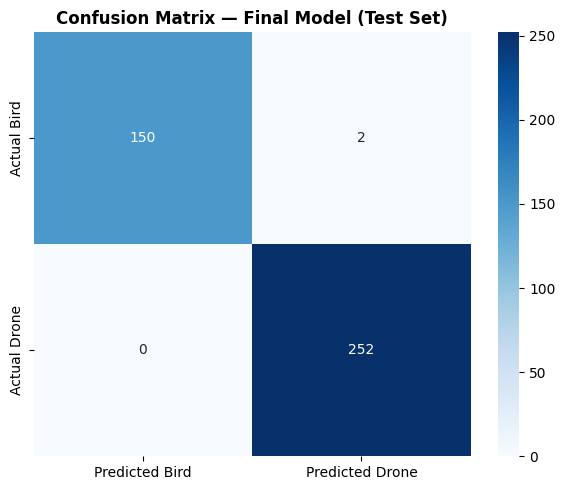


Classification Report:
              precision    recall  f1-score   support

        Bird       1.00      0.99      0.99       152
       Drone       0.99      1.00      1.00       252

    accuracy                           1.00       404
   macro avg       1.00      0.99      0.99       404
weighted avg       1.00      1.00      1.00       404

  True Negatives  (Bird→Bird):   150
  False Positives (Bird→Drone):  2  ← bird misclassified as drone
  False Negatives (Drone→Bird):  0  ← drone misclassified as bird (more dangerous)
  True Positives  (Drone→Drone): 252


In [15]:
# ── Confusion Matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted Bird', 'Predicted Drone'],
            yticklabels=['Actual Bird', 'Actual Drone'])
ax.set_title('Confusion Matrix — Final Model (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['Bird', 'Drone']))

tn, fp, fn, tp = cm.ravel()
print(f'  True Negatives  (Bird→Bird):   {tn}')
print(f'  False Positives (Bird→Drone):  {fp}  ← bird misclassified as drone')
print(f'  False Negatives (Drone→Bird):  {fn}  ← drone misclassified as bird (more dangerous)')
print(f'  True Positives  (Drone→Drone): {tp}')

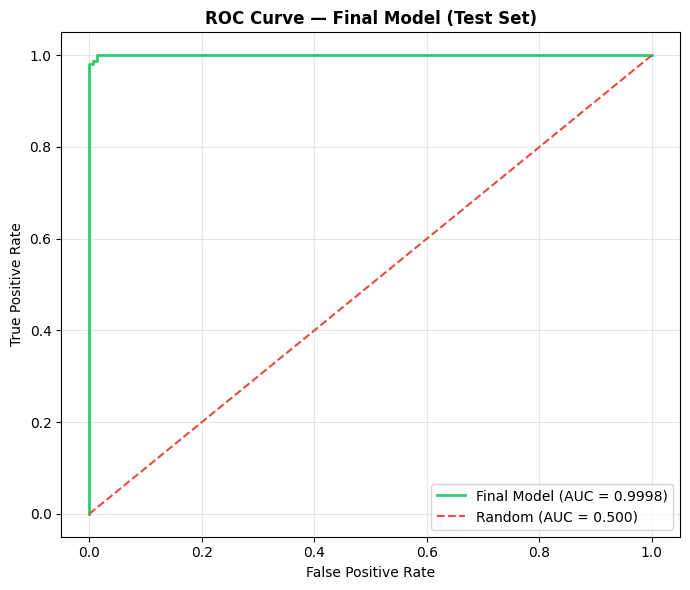

In [16]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#2ecc71', lw=2, label=f'Final Model (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='#e74c3c', linestyle='--', lw=1.5, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Final Model (Test Set)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Total misclassified: 2 / 404


2026-03-10 05:05:19.171528: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


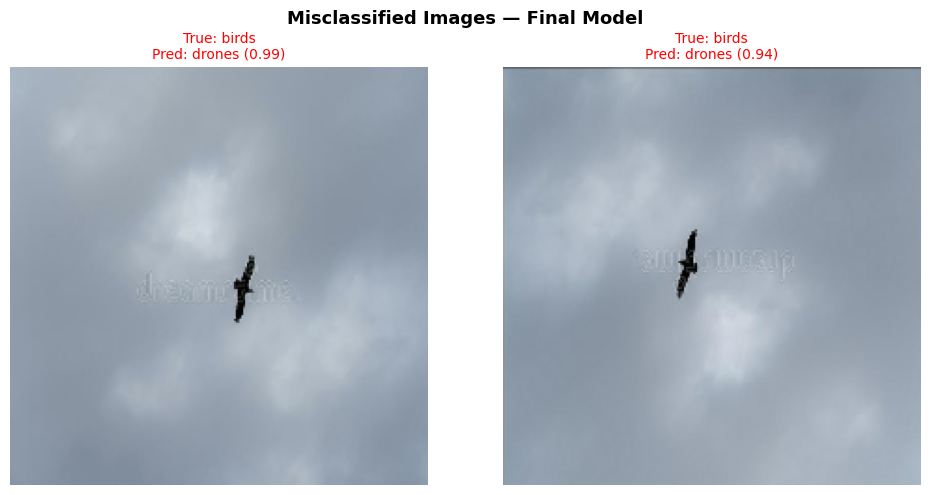

In [17]:
# ── Visualize misclassified images ────────────────────────────────────────────
all_images, all_labels, all_probs = [], [], []
for images, labels in test_ds_mobile:
    preds = model_frozen.predict(images, verbose=0)
    all_images.extend(images.numpy())
    all_labels.extend(labels.numpy().flatten())
    all_probs.extend(preds.flatten())

all_images = np.array(all_images)
all_labels = np.array(all_labels)
all_preds  = (np.array(all_probs) > 0.5).astype(int)

misclassified = np.where(all_labels != all_preds)[0]
print(f'Total misclassified: {len(misclassified)} / {len(all_labels)}')

n_show = len(misclassified)
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
if n_show == 1:
    axes = [axes]
fig.suptitle('Misclassified Images — Final Model', fontsize=13, fontweight='bold')

for i, idx in enumerate(misclassified):
    img_display = np.clip((all_images[idx] + 1) / 2.0, 0, 1)
    axes[i].imshow(img_display)
    true_label = CLASS_NAMES[int(all_labels[idx])]
    pred_label = CLASS_NAMES[int(all_preds[idx])]
    conf = all_probs[idx] if all_preds[idx] == 1 else 1 - all_probs[idx]
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label} ({conf:.2f})', fontsize=10, color='red')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Error Analysis Findings

**Common error patterns:**

1. Both misclassified images are watermarked bird photos, the watermark text is clearly visible in both, adding artificial texture that corrupts the pixel signal the model relies on.

2. Both birds appear as small dark silhouettes with rigid outstretched wings against an overcast grey sky, but to a human person they are 100% birds.

3. The model was almost certain, it predicted drone with 0.99 and 0.94 confidence, I interpret this as the watermarked images being genuinely misleading.

**Why do these errors occur?**
Both errors trace directly to the data quality issue flagged in EDA, watermarked bird images were identified as a known problem before any model was trained. These are data failures, not model failures.

**What could potentially fix these errors?**
Removing or manually filtering the watermarked bird images identified in EDA would be the highest impact fix, the model itself is working correctly.

## 3.3 Key Insights

**What techniques had the biggest impact on performance?**
Transfer learning (MobileNetV2) produced the largest single jump, leveraging 1.2M ImageNet training examples through pretrained feature extractors gave an immediate advantage over anything trained from scratch.

**What surprised you about this problem?**
The logistic regression baseline scoring 82.7% was surprising, we discussed it in class being an unexplored option by some so I was interested in testing it. It suggested the resolution gap between classes (birds at 328×239px vs drones at 1981×1193px) was providing strong pixel-level signal even without any spatial reasoning. This made the CNN's job harder to justify.

**If you had more time, what would you try next?**
Cleaning the noisy bird images identified in EDA would likely improve results more than any model change.

---
# Part 4: LLM Collaboration Documentation

## 4.1 LLM Usage Summary

**Which LLM(s) did you use?** Both ChatGPT and Claude for confirmation.

**Approximate number of interactions:** Over 100

**Primary ways you used LLM assistance:**
- [x] Understanding concepts
- [x] Writing code
- [x] Debugging errors
- [x] Optimizing performance
- [x] Architecture decisions
- [x] Documentation/explanation

## 4.2 Most Valuable LLM Interactions

### Interaction 1 : Understanding GlobalAveragePooling2D vs Flatten

**My prompt:**
```
The model summary shows 12.9M parameters which is too big for my set?
```

**Key insight from response:** The LLM explained that Flatten produces a 100,352 element vector from a 28×28×128 feature map, and connecting that to Dense(128) alone creates 12.8M parameters, a 3,936:1 parameter-to-sample ratio that guarantees overfitting. GlobalAveragePooling2D averages each feature map to a single value, reducing that vector to 128 elements and the parameter count to 110K.

**How it helped:** Prevented a broken first experiment. The fix was made before any training began, saving wasted time and compute.

---

### Interaction 2 : Debugging the Logistic Regression Label Bug

**My prompt:**
```
Birds: 0 | Drones: 613. Why are there zero birds in my loaded dataset?
```

**Key insight from response:** The LLM identified that `.DS_Store` in the directory was pushing the alphabetical class index off by one, birds got label 1 instead of 0, and drones got label 2 instead of 1. The fix was to use an explicit CLASS_MAP dictionary instead of relying on sorted directory listing.

**How it helped:** The first logistic regression result (86.3%) took literal hours and was completely invalid, the model had never seen a single bird.

---

### Interaction 3 : Understanding Why Val Loss Monitors Better Than Val Accuracy

**My prompt:**

Why didn't EarlyStopping pick epoch 22 which had higher val accuracy than epoch 24?


**Key insight from response:** Loss is a continuous signal that captures every small improvement even when accuracy doesn't move. Accuracy only changes when the model crosses the 0.5 prediction threshold, so it can stay flat for several epochs while the model is genuinely improving internally.

**How it helped:** Clarified a fundamental concept about training monitoring that applies to every future model I build.

---

### Interaction 4 : Understanding Class Weights vs Augmentation

**My prompt:**

do we need both class weights and augmentation? 


**Key insight from response:** They solve different problems. Class weights fix a counting problem, they tell the loss function to penalize minority class errors more heavily. Augmentation fixes a diversity problem, it generates new training examples to reduce overfitting. A model can be correctly weighted but still overfit to the limited visual diversity of 1,607 bird images.

**How it helped:** I understood why both were necessary and could explain the decision in my methodology with confidence.

---

### Interaction 5 : Understanding What AUC Measures vs Accuracy

**My prompt:**

Experiment 2 only improved accuracy by 0.4% over Exp 1 but AUC jumped by 0.020. Explain the implication.


**Key insight from response:** AUC measures how well the model separates the two classes across all possible thresholds, it captures whether the model is more confident when it's right. A jump from 0.965 to 0.985 means the model became significantly better calibrated even though raw accuracy barely moved. For safety-critical applications like drone detection, this matters more than accuracy.

**How it helped:** Reframed how I interpret results, AUC became my primary metric for evaluating genuine model improvement throughout the project.

## 4.3 LLM Limitations Encountered

### Limitation 1 — Broken Initial Logistic Regression Code

**What I asked:** Build a logistic regression baseline using `keras.utils.image_dataset_from_directory`.

**What was wrong with the response:** The code used `image_dataset_from_directory` with `batch_size=N_SAMPLES` and `lr_ds.take(1)` to load images. This ran for over hours without completing and silently loaded zero bird images due to the `.DS_Store` label offset issue.

**How I identified the problem:** After running for an hour with no output I added debug print statements that revealed `Birds: 0 | Drones: 613` the labels were completely wrong.

**What I did instead:** Switched to PIL-based manual image loading with explicit class labels (`CLASS_MAP = {'birds': 0, 'drones': 1}`), progress printing every 100 images, and balanced sampling of 750 per class. This ran in 15 seconds.

---

### Limitation 2 — Overconfident Architecture Suggestion

**What I asked:** Suggest an initial CNN architecture for binary image classification.

**What was wrong with the response:** The LLM suggested using `Flatten` before the Dense layer without checking or warning about the resulting parameter count. For a 224×224 input this produced 12.9M parameters, entirely inappropriate for a dataset of 3,284 images.

**How I identified the problem:** I ran `model.summary()` and inspected the parameter count before training. The 12,938,561 total parameters immediately flagged as too high.

**What I did instead:** Replaced `Flatten` with `GlobalAveragePooling2D` on my own initiative, reducing parameters from 12.9M to 110K. The LLM confirmed this was the right fix when asked, but it should have caught it in the first suggestion.

## 4.4 Prompting Evolution

**How did your prompting strategy change from Week 7 to Week 8?**
in the first weeks my prompts were vague requests for code because I expected the LLM to understand from context everything. In later weeks I was more specific but was typing longer prompts sometimes. By Week 8 I was providing context while staying concise and asking for explanations alongside code which produced much more useful and accurate responses.

**Example of an early prompt that didn't work well:**

Build a logistic regression baseline for my image classification project.

**How I would rewrite it now:**

I have 4,106 images (1,607 birds, 2,499 drones) in two folders under ../data/raw.
Build a logistic regression baseline to load images manually at 32x32, with label assignment (birds=0, drones=1), balanced sampling of 750 per class, and progress printing every 100 images. Explain why each choice was made.

**Top 3 prompting tips for future students:**

1. Always provide relevant info such as dataset size, class counts, and current results when asking for architecture or code suggestions, the LLM cannot make good decisions without knowing the scale of your problem.

2. Never run LLM-generated code without reviewing it first. Learned this from our second/third lecture in class.

3. If something is wrong or doesn't add up, add debugging steps to see what is happening while the model is running.

---
# Part 5: Course Retrospective

## 5.1 Technical Growth

### Skills Self-Assessment

| Skill | Start | End | Notes |
|-------|-------|-----|-------|
| Building neural networks from scratch | 4 | 5 | Built and iterated multiple architectures |
| Understanding backpropagation/gradients | 2 | 5 | I learned why learning rate and loss function choices matter |
| Implementing CNNs | 1 | 5 | Designed CNNs for different kinds of datasets over the course of this class|
| Transfer learning | 1 | 5 | Applied MobileNetV2 and learned how TL works |
| NLP with neural networks | 1 | 5 | Learned about sequence models and transformers |
| Regularization techniques | 1 | 5 | Learned and applied Dropout, BatchNorm, class weights, and data augmentation across many assignments |
| Debugging deep learning models | 1 | 5 | Learned debugging techniques |
| Reading/using Keras documentation | 2 | 5 | Navigated layers, callbacks, metrics, and preprocessing APIs throughout the project |
| Hyperparameter tuning | 4 | 5 | Learned to tune learning rate, dropout, batch size, patience, and layer depth |
| Working effectively with LLM assistants | 2 | 5 | Learned to prompt better, verify LLM suggestions and catch errors before running |

### Concept Mastery

**Which concept took the longest to understand?**
The difference between deep learning and machine learning. I understood that they were related but struggled to articulate where one ends and the other begins.

**How did you eventually understand it?**
Youtube videos and analogies mostly, I can explain it better that I tested it, in this capstone for example, logistic regression, a classical ML model, score 82.7% on the same problem a deep CNN scored 91.8% on. The difference was the CNN's ability to learn spatial features automatically rather than relying on flattened pixels.

**Which concept are you most confident about now?**
CNN architecture design. After building multiple from scratch, I feel confident reading a model summary, understanding what each layer does, and knowing what needs changing.

**Which concept do you still find confusing?**
Transformer attention mechanisms. I understand the high-level idea of tokens attending to each other, but the math behind it still feels like a black box I have not fully opened yet, but I will.

## 5.2 Week-by-Week Reflection

| Week | Topic | My Key Takeaway |
|------|-------|----------------|
| 1 | Foundations | Neural networks are just nested functions where layers transform inputs into outputs through learned weights |
| 2 | Classification/Regression | The loss function defines what the model optimizes, choosing the right one matters |
| 3 | Optimization/Regularization | Learning rate is a very important hyperparameter, too high diverges, too low stagnates |
| 4 | CNNs | Convolution preserves structure that logistic regression throws away |
| 5 | Transfer Learning | Pretrained weights are like introducing intelligence and we need to use them when we can, 1.2M ImageNet images beat training from scratch on 3K images |
| 6 | NLP/Transformers | Attention lets models focus on relevant context regardless of position |
| 7-8 | Capstone | A 99.5% test accuracy model still makes 2 mistakes, and both trace back to bad data, so data quality is important |

## 5.3 LLM Collaboration Reflection

**How has using LLMs as coding partners changed how you approach learning?**
It changed where I spend my time. Before I would get stuck on a random error for hours. Now I get past that quickly and spend more time actually thinking about why my model is behaving the way it is. 

**What are the benefits of LLM-assisted learning?**
Getting an explanation right when I need it and one that is custom to my situation.

**What are the risks or downsides?**
It can be wrong and it will be confident still. Twice in this project the LLM gave me code that looked completely reasonable but was broken. If I had just run the code and trusted the output I would have never caught either of those.

**How do you ensure you're actually learning, not just copying?**
I made sure I could explain every decision before moving on. More importantly I ask myself most times what the answer would look like and then I ask the LLM and then compare.

### Before & After Comparison

**How I approached coding problems BEFORE this course:**
I used to rely on lecture notes and code instead of building code and using the LLM and collaborator.

**How I approach coding problems NOW:**
Use the LLM to get started, immediately check that the output actually makes sense, ask questions about anything unclear, and read the LLM suggestions but use my own judgement.

**Has your view of AI/LLM tools changed? How?**
Not a lot but yes. I knew of APIs and using the LLM in terminals but haven't used them until I started this class and that does save time. 


## 5.4 Looking Forward

**How do you plan to continue developing your deep learning skills?**
Yes, I plan to pick projects and go over them from start to end to practice more, and then apply that into projects of my interest.

**What specific projects or domains interest you?**
Anything that contributes to making life easier, such as automating tedious, repetitive, or time consuming tasks.

**How will you use deep learning in your career?**
In banking, I would like to test deep learning to  help identify unusual transaction patterns that traditional rule-based systems miss, which is directly relevant to fraud detection and risk management in banking. Some fraud patterns are not simple as people are always trying to get around detection systems.

**What resources will you use for continued learning?**
Claude AI, Research papers, Youtube.

## 5.5 Final Thoughts

### Open Reflection (200–400 words)

This course was the first challenging since I started this degree in 2024. I expected a very intuitive addition to the other classes. Coming in I knew what machine learning was but deep learning felt like a completely different concept. By the end I learned and understood the concept, built models from scratch, learn to detect and fix bugs, learned to make my own architecture decisions, and saw progress.

The thing I am most proud of is how the project came together as a logical progression. Every experiment built on the one before it. I started with a naive baseline, moved to logistic regression, then built CNNs from scratch, and finally applied transfer learning. Each step had a reason and each result told me something that informed the next decision. Watching the accuracy go from 60.9% to 82.7% to 91.8% to 98.3% to 99.5% in a straight line made the whole process feel like it actually made sense rather than just trying things randomly and hoping for improvement.

The biggest challenge was that I was building models before I fully understood the concepts behind them. By the end I could see the output and know if it makes sense logically or not.

The LLM collaboration made things much easier, it made it possible to go deeper and work faster. Instead of spending hours stuck on syntax I could spend that time understanding what my output means and what the best next step is.

My advice to future students is three things. Give the LLM context before asking for code, it cannot help you properly if it does not know your dataset size or what you have already tried. Never run generated code without reading it first, that habit alone saved me from two broken experiments. And if something looks wrong, add a print statement and find out, do not just hope it works out.

For me this course fits into a career in banking where the problems are fundamentally about finding signal in messy data. Deep learning gives me a more powerful toolkit to bring to those problems than what I had before this course.

---

---

# Submission Checklist

Before submitting, verify:

## Technical Requirements
- [x] All code cells run without errors (restart kernel and run all)
- [x] Dataset is clearly identified and accessible
- [x] EDA is thorough with visualizations
- [x] At least 3 experiments documented
- [x] Final model architecture is clearly presented
- [x] Results beat baseline performance
- [ ] Kaggle submission screenshot/proof included - This dataset is a Kaggle dataset download and not an active competition. From what I remember from the course lecture, this section is optional pending further consideration. The held-out 10% test set was used as the final evaluation equivalent, producing a test accuracy of 99.50% and AUC of 0.9998.

## Analysis Requirements
- [x] Complete results comparison table
- [x] Error analysis with specific examples
- [x] Key insights documented

## LLM Documentation Requirements
- [x] At least 5 useful LLM interactions documented
- [x] At least 2 LLM limitations discussed
- [x] Prompting evolution described

## Retrospective Requirements
- [x] Skills self-assessment completed
- [x] Week-by-week takeaways filled in
- [x] LLM collaboration reflection thoughtful
- [x] Final reflection is 200-400 words

## Quality Requirements
- [x] Notebook is well-organized and readable
- [x] Markdown cells explain reasoning
- [x] Code is commented where appropriate
- [x] All questions are answered completely

---